# Graph Convolutional Network to Overcome Navigation Challenges

By: Apurvata Kumar

Updated: March 2026

In [64]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import networkx as nx
import matplotlib.pyplot as plt
import torch
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import torch.nn.functional as nf
from torch.nn import MSELoss

Change below file paths as needed.

In [65]:
# Import customized datasets
simple_file = '/content/custom_data_simple.csv'
# For both medium and complex datasets
complex_file = '/content/custom_data_complex.csv'

Using three types of datasets for three phases. I am commenting out the others when one dataset is in use.

Use country code/latitude/longitude keywords for the medium and complex dataset.

In [66]:
# Create dataset for "simple" phase
df = pd.read_csv(simple_file).iloc[2:53]

# Convert longitude and latitude to integer for simple phase
df['usa_state_longitude'] = df['usa_state_longitude'].fillna(0).astype(int)
df['usa_state_latitude'] = df['usa_state_latitude'].fillna(0).astype(int)

# Select 5 rows at random for 10 different sets (8 for training and 2 for testing)
df_simple1 = df.sample(n=5)
df_simple2 = df.sample(n=5)
df_simple3 = df.sample(n=5)
df_simple4 = df.sample(n=5)
df_simple5 = df.sample(n=5)
df_simple6 = df.sample(n=5)
df_simple7 = df.sample(n=5)
df_simple8 = df.sample(n=5)
# For testing
df_simple9 = df.sample(n=5)
df_simple10 = df.sample(n=5)

display(df_simple1)
display(df_simple2)

,usa_state_code,usa_state_latitude,usa_state_longitude
40,RI,41,-71
36,OK,35,-97
28,ND,47,-101
33,NV,38,-116
41,SC,33,-81


,usa_state_code,usa_state_latitude,usa_state_longitude
27,NC,35,-79
22,MI,44,-85
36,OK,35,-97
24,MO,37,-91
51,WY,43,-107


In [67]:
# Create dataset for "medium" phase
df = pd.read_csv(complex_file).iloc[2:246]

# Select 10 rows at random for 10 different sets (8 for training and 2 for testing)
df_medium1 = df.sample(n=10)
df_medium2 = df.sample(n=10)
df_medium3 = df.sample(n=10)
df_medium4 = df.sample(n=10)
df_medium5 = df.sample(n=10)
df_medium6 = df.sample(n=10)
df_medium7 = df.sample(n=10)
df_medium8 = df.sample(n=10)
# For testing
df_medium9 = df.sample(n=10)
df_medium10 = df.sample(n=10)

display(df_medium1)
display(df_medium2)

,country_code,country_latitude,country_longitude
235,VN,14.058324,108.277199
182,PY,-23.442503,-58.443832
74,GD,12.262776,-61.604171
139,MH,7.131474,171.184478
228,UY,-32.522779,-55.765835
28,BR,-14.235004,-51.925280
122,KZ,48.019573,66.923684
111,JP,36.204824,138.252924
89,GW,11.803749,-15.180413
20,BF,12.238333,-1.561593


,country_code,country_latitude,country_longitude
90,GY,4.860416,-58.930180
198,SK,48.669026,19.699024
164,NP,28.394857,84.124008
208,TC,21.694025,-71.797928
113,KG,41.204380,74.766098
170,PE,-9.189967,-75.015152
27,BO,-16.290154,-63.588653
35,CA,56.130366,-106.346771
220,TT,10.691803,-61.222503
192,SD,12.862807,30.217636


In [68]:
# Create dataset for "complex" phase
df = pd.read_csv(complex_file).iloc[2:246]

# Select 25 rows at random for 10 different sets (8 for training and 2 for testing)
df_complex1 = df.sample(n=25)
df_complex2 = df.sample(n=25)
df_complex3 = df.sample(n=25)
df_complex4 = df.sample(n=25)
df_complex5 = df.sample(n=25)
df_complex6 = df.sample(n=25)
df_complex7 = df.sample(n=25)
df_complex8 = df.sample(n=25)
# For testing
df_complex9 = df.sample(n=25)
df_complex10 = df.sample(n=25)

display(df_complex1)
display(df_complex2)

,country_code,country_latitude,country_longitude
170,PE,-9.189967,-75.015152
226,UM,NaN,NaN
242,ZA,-30.559482,22.937506
138,MG,-18.766947,46.869107
73,GB,55.378051,-3.435973
40,CH,46.818188,8.227512
221,TV,-7.109535,177.649330
218,TO,-21.178986,-175.198242
125,LC,13.909444,-60.978893
235,VN,14.058324,108.277199


,country_code,country_latitude,country_longitude
133,LY,26.335100,17.228331
46,CO,4.570868,-74.297333
162,NL,52.132633,5.291266
84,GQ,1.650801,10.267895
129,LS,-29.609988,28.233608
75,GE,42.315407,43.356892
107,IT,41.871940,12.567380
20,BF,12.238333,-1.561593
235,VN,14.058324,108.277199
108,JE,49.214439,-2.131250


If any of the data points are null, we can rerun the code to regenerate random values that are not null.

***For the below code, the dataset can be changed to other simple or complex sets created above.***

As an example, only one dataset is used for the program.

In [69]:
# Pick a dataset
data = df_simple1.copy()

In [70]:
# Normalize datasets between the range [0, 1] using MinMaxScalar
scaler = MinMaxScaler()

df_simple1_norm = data.copy()
columns = ['usa_state_latitude', 'usa_state_longitude']
df_simple1_norm[columns] = scaler.fit_transform(df_simple1_norm[columns])

display(df_simple1_norm)

,usa_state_code,usa_state_latitude,usa_state_longitude
40,RI,0.571429,1.000000
36,OK,0.142857,0.422222
28,ND,1.000000,0.333333
33,NV,0.357143,0.000000
41,SC,0.000000,0.777778


In [71]:
# Convert (longitude, latitude) to cartesian coordinates (x, y)
df_simple1_cart = df_simple1_norm.copy()
df_simple1_cart['x'] = df_simple1_norm['usa_state_longitude']
df_simple1_cart['y'] = df_simple1_norm['usa_state_latitude']

df_simple1_cart = df_simple1_cart[['usa_state_code', 'x', 'y']].copy()

display(df_simple1_cart)

,usa_state_code,x,y
40,RI,1.000000,0.571429
36,OK,0.422222,0.142857
28,ND,0.333333,1.000000
33,NV,0.000000,0.357143
41,SC,0.777778,0.000000


This step converts the imported dataset into a custom normalized version using cartesian coordinates with values between 0 and 1.

In [72]:
# Add random noise to reduce overfitting
noise_val = 0.0003

df_simple1_cart['x'] = df_simple1_cart['x'] + np.random.normal(0, noise_val, size=len(data))
df_simple1_cart['y'] = df_simple1_cart['y'] + np.random.normal(0, noise_val, size=len(data))

display(df_simple1_cart)

,usa_state_code,x,y
40,RI,1.000183,0.571858
36,OK,0.422235,0.142812
28,ND,0.333017,1.000221
33,NV,-0.000137,0.357450
41,SC,0.777713,0.000493


After dataset is customized, the nodes (state or country codes) can be represented as a graph with edges (distance between nodes).

In [73]:
# Set the customized/normalized dataset as the new data variable
data_custom = df_simple1_cart.copy()

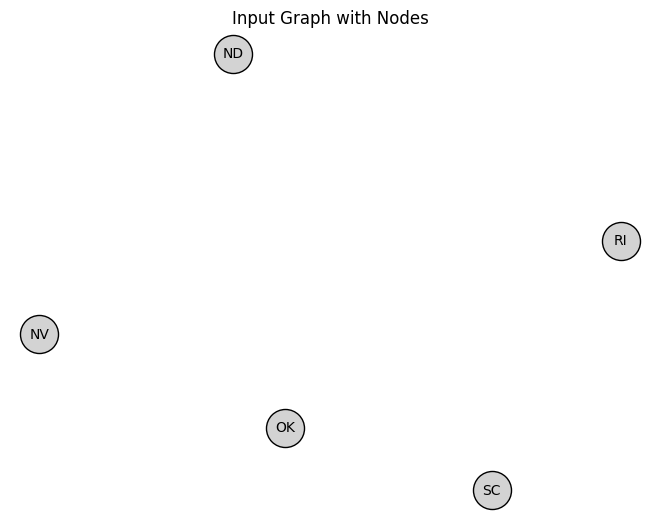

,usa_state_code,x,y
40,RI,1.000183,0.571858
36,OK,0.422235,0.142812
28,ND,0.333017,1.000221
33,NV,-0.000137,0.357450
41,SC,0.777713,0.000493


In [74]:
# Build a simple graph for the input
G = nx.Graph()

# Use state code as nodes
for id, row in data_custom.iterrows():
    G.add_node(row['usa_state_code'], pos=(row['x'], row['y']))

info = data_custom[['usa_state_code', 'x', 'y']]
pos = nx.get_node_attributes(G, 'pos')

nx.draw(G, pos, with_labels=True, node_color='lightgrey', node_size=750, font_size=10, font_color='black', edgecolors='black')
plt.title('Input Graph with Nodes')
plt.show()

display(info)

Calculate the distance between nodes using the "Distance Formula":

***d = sqrt((x2 - x1)^2 + (y2 - y1)^2)***

Note: The distance is inversed because farther distance has lower weights on the edges.

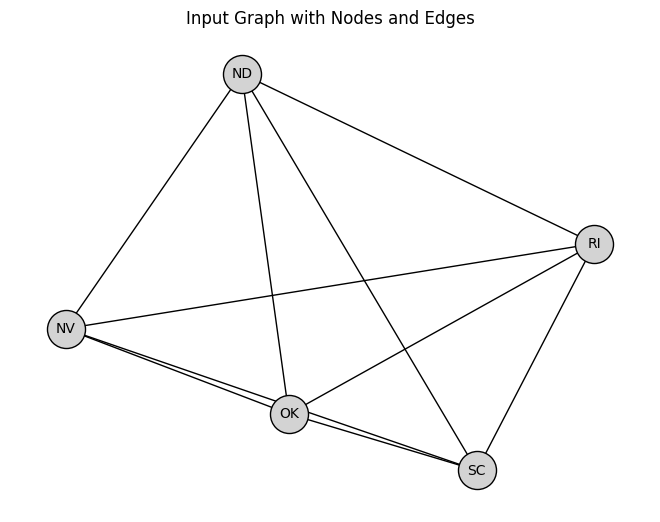

,usa_state_code,x,y
40,RI,1.000183,0.571858
36,OK,0.422235,0.142812
28,ND,0.333017,1.000221
33,NV,-0.000137,0.357450
41,SC,0.777713,0.000493


In [75]:
# Add edges based on the distance (inverse) between nodes
for i in range(len(info)):
  for j in range(i+1, len(info)):
    x1 = info.iloc[i]['x']
    x2 = info.iloc[j]['x']
    y1 = info.iloc[i]['y']
    y2 = info.iloc[j]['y']

    # Distance between nodes
    d = np.sqrt((x1-x2)**2 + (y1-y2)**2)

    # Weight of edges (inverse of distance = the farther the node, the lower the weight)
    w = 1/d if d>0 else 0

    G.add_edge(info.iloc[i]['usa_state_code'], info.iloc[j]['usa_state_code'], weight=w)

pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, with_labels=True, node_color='lightgrey', node_size=750, font_size=10, font_color='black', edgecolors='black')
plt.title('Input Graph with Nodes and Edges')
plt.show()

display(info)

Adding weights directly to the graph's edges. This is different than the weights/bias parameters in neural networks.

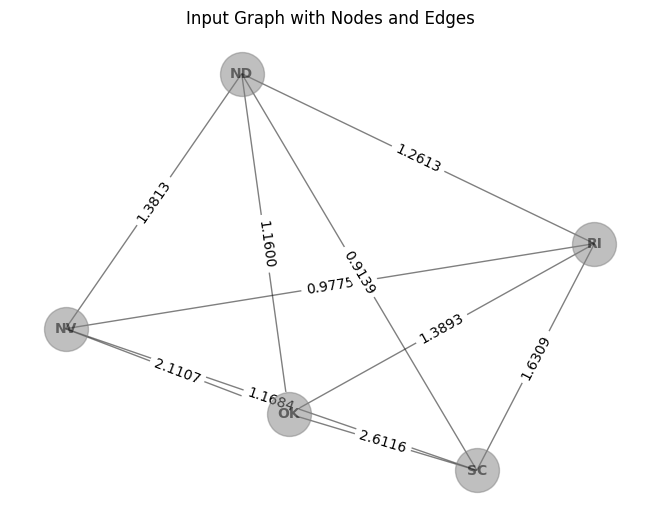

{('RI', 'OK'): np.float64(1.3892856955006985),
 ('RI', 'ND'): np.float64(1.2612782913334974),
 ('RI', 'NV'): np.float64(0.9774790506838313),
 ('RI', 'SC'): np.float64(1.6309267382262824),
 ('OK', 'ND'): np.float64(1.1600407881967518),
 ('OK', 'NV'): np.float64(2.110683391141865),
 ('OK', 'SC'): np.float64(2.61158985416968),
 ('ND', 'NV'): np.float64(1.3812542170594433),
 ('ND', 'SC'): np.float64(0.9139336274768011),
 ('NV', 'SC'): np.float64(1.1684377631846088)}

In [76]:
from numpy.random.mtrand import f
pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, with_labels=True, node_color='grey', node_size=1000, font_size=10, font_color='black', font_weight='bold', edge_color='black', alpha=0.5)

# Add weights to the graph's edges
edge_attributes = nx.get_edge_attributes(G, 'weight')

# Add weights with 4 decimal places (Gemini AI)
edge_labels_attributes = {k: f'{v:.4f}' for k, v in edge_attributes.items()}

# Draw edges
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_attributes, font_color='black', font_size=10)
plt.title('Input Graph with Nodes and Edges')
plt.show()

# Show the edge weights
display(nx.get_edge_attributes(G, 'weight'))


Add random noise and remove 2-3 random edges to make it suitable for the input graph.

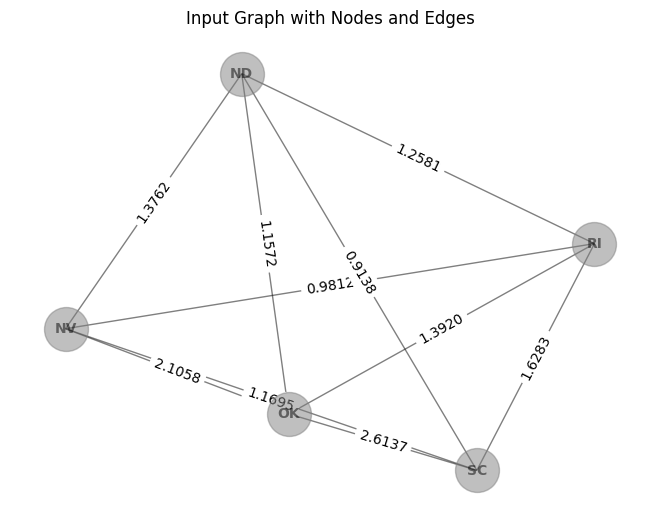

{('RI', 'OK'): np.float64(1.3920383098798386),
 ('RI', 'ND'): np.float64(1.2581041875561707),
 ('RI', 'NV'): np.float64(0.9812471132420444),
 ('RI', 'SC'): np.float64(1.6282948033487599),
 ('OK', 'ND'): np.float64(1.157185113607145),
 ('OK', 'NV'): np.float64(2.1058058175817678),
 ('OK', 'SC'): np.float64(2.6136930035540358),
 ('ND', 'NV'): np.float64(1.3761903464814238),
 ('ND', 'SC'): np.float64(0.9138197164041189),
 ('NV', 'SC'): np.float64(1.1694613401893397)}

In [77]:
# Variables
random_noise = 0.003
edges_to_remove = 3
edge_threshold = 0.75
i = 0

# Remove "random_edges_to_remove" number of edges from the graph
while i < edges_to_remove:
  # Collect edges to remove
  collect_edges = []
  for u, v, data in G.edges(data=True):
    # Remove only edges that are less than "edge_threshold" because distance is too far
    if data['weight'] < edge_threshold:
      collect_edges.append((u, v))
    # If not removed, add random noise
    else:
      data['weight'] = data['weight'] + np.random.normal(0, random_noise)
    i+=1
  G.remove_edges_from(collect_edges)


# Draw graph again

pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, with_labels=True, node_color='grey', node_size=1000, font_size=10, font_color='black', font_weight='bold', edge_color='black', alpha=0.5)

# Add weights to the graph's edges
edge_attributes = nx.get_edge_attributes(G, 'weight')
edge_labels_attributes = {k: f'{v:.4f}' for k, v in edge_attributes.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_attributes, font_color='black', font_size=10)

plt.title('Input Graph with Nodes and Edges')
plt.show()

# Show the edge weights
display(nx.get_edge_attributes(G, 'weight'))



Find two random rows for source and destination for the input. If 0, retry the code until both are not null.

In [78]:
# Pick 2 random nodes

# Input Source
source = np.random.randint(0, len(data_custom))
# Input Destination
dest = np.random.randint(0, len(data_custom))

display(source, dest)

source_node = data_custom.iloc[source]
dest_node = data_custom.iloc[dest]

display(source_node, dest_node)

4

2

,41
usa_state_code,SC
x,0.777713
y,0.000493


,28
usa_state_code,ND
x,0.333017
y,1.000221


This data needs to be in tensor format in order to be used as data in the GNN/GCN model.

In [79]:
# Convert graph to tensor data
nodes = list(G.nodes)
edges = list(G.edges)

nodes_map = {node: i for i, node in enumerate(data_custom['usa_state_code'])}

tensor_map = []
for node in nodes:
  if node in nodes_map:
    node_tmp = nodes_map[node]
    tensor_map.append(data_custom.iloc[node_tmp][['x','y']].values)
  tensor_map.append([0.0, 0.0])

x = torch.tensor(tensor_map, dtype=torch.float)

source_tmp = [{name: i for i, name in enumerate(nodes)}[u] for u, v in edges]
dest_tmp = [{name: i for i, name in enumerate(nodes)}[v] for u, v in edges]

edge_index = torch.tensor([source_tmp, dest_tmp], dtype=torch.long)

# min, number of classification, size of layers, type)
y = torch.randint(0, 10, [2,4], dtype=torch.long)

# Create the data for the model
data = Data(x=x, edge_index=edge_index, y=y)

display(data)
display(data.num_nodes)
display(data.num_edges)

Data(x=[10, 2], edge_index=[2, 10], y=[2, 4])

10

10

In [80]:
# Parameters for Simple Phase
num_node_features = 2 # for x and y
input_size = 2
hidden_layer_size = 4
output_size = 2
num_hidden_layers = 2

In [81]:
# Create a GNN model for Simple Phase
class GNN(torch.nn.Module):
  def __init__(self, input_size, hidden_layer_size, output_size):
    super(GNN, self).__init__()
    self.conv1 = GCNConv(input_size, hidden_layer_size)
    self.conv2 = GCNConv(hidden_layer_size, output_size)

  # Define forward pass
  def forward(self, data):
    x, edge_index = data.x, data.edge_index
    x = self.conv1(x, edge_index)
    # ReLU activation function
    x = nf.relu(x)
    # Another hidden layer (convolutional layer)
    x = self.conv2(x, edge_index)
    return x

  # Define backpropagation
  def backward(self, data):
    # Loss function
    x = MSELoss()
    # SoftMax to calculate probabilities on columns
    return nf.log_softmax(x, dim=1)

# Initialize model
model = GNN(input_size, hidden_layer_size, output_size)

# Display model
display(model)



GNN(
  (conv1): GCNConv(2, 4)
  (conv2): GCNConv(4, 2)
)

In [82]:
# Create a GCN model for Simple Phase
class GCN(torch.nn.Module):
  def __init__(self, num_node_features, hidden_layer_size):
    super(GNN, self).__init__()
    self.conv1 = GCNConv(num_node_features, hidden_layer_size)
    self.conv2 = GCNConv(num_node_features, hidden_layer_size)

  # Define forward pass
  def forward(self, data):
    x, edge_index = data.x, data.edge_index
    x = self.conv1(x, edge_index)
    # ReLU activation function
    x = nf.relu(x)
    # Another hidden layer (convolutional layer)
    x = self.conv2(x, edge_index)
    return x

  # Define backpropagation
  def backward(self, data):
    # Loss function
    x = MSELoss()
    # SoftMax to calculate probabilities on columns
    return nf.log_softmax(x, dim=1)

# Initialize model
model = GNN(input_size, hidden_layer_size, output_size)

# Display model
display(model)


GNN(
  (conv1): GCNConv(2, 4)
  (conv2): GCNConv(4, 2)
)

Now that the model is defined, the A* method can be used in the output layer to find the optimized path from source_node to dest_node in the graph.

In this case, the edges are used to define the shortest path to keep the variables for the project simple.

In [83]:
# A* algorithm for shortest path calculation
def a_star(graph, start, goal):
  return 0

In [84]:
# Parameters for Medium Phase
input_size = 2
hidden_layer_size = 8
output_size = 2
num_hidden_layers = 3

# Parameters for Complex Phase
input_size = 2
hidden_layer_size = 64
output_size = 2
num_hidden_layers = 5